Histórico dos operadores genéticos.
http://deap.readthedocs.io/en/master/api/tools.html#history


In [93]:
!pip install deap
!sudo apt-get install python3-dev graphviz libgraphviz-dev pkg-config
!pip install pygraphviz
!pip install matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pkg-config is already the newest version (0.29.2-1ubuntu3).
python3-dev is already the newest version (3.10.6-1~22.04.1).
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'sudo apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [94]:
import warnings
warnings.filterwarnings('ignore')

In [95]:
import array
import random
import numpy

from deap import algorithms
from deap import base
from deap import creator
from deap import tools


In [96]:
# Gera o toolbox responsável por registrar as configurações dp framework
toolbox = base.Toolbox()

# Cria o tipo de função fitness e indivíduo
creator.create("Maximization", base.Fitness, weights=(1.0,))
creator.create("Genes", list, fitness=creator.Maximization)

# Registra os nomes e osa tipos de indivíduo, fitness e população
toolbox.register("Atributo", random.randint, 0, 1)
toolbox.register("Cromossomo", tools.initRepeat, creator.Genes, toolbox.Atributo, 50) # 50 bits de 0 e 1
toolbox.register("Populacao", tools.initRepeat, list, toolbox.Cromossomo) # é uma lista de listas que são cromossomos


In [97]:
def fitnessFunction(chromosome):
  return sum(chromosome),

In [98]:
# Parâmetros dos Algoritmos
prob_cx=0.8
prob_mt=0.1
nger=5
tamPop=20

# Estratégia Evolutiva (Mu_Lambda)
mu = 20
_lambda = 20

In [99]:
# Bibliotecas gráficas
import matplotlib.pyplot as plt
import networkx
from networkx.drawing.nx_agraph import graphviz_layout

I. eaSimple

In [100]:
# Registra os operadores. Deve-se manter os nomes evaluate, mate, mutate e select.
toolbox.register("evaluate", fitnessFunction)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.01)
toolbox.register("select", tools.selBest)

In [101]:
# Gera o objet history
histEA = tools.History()
toolbox.decorate("mate", histEA.decorator)
toolbox.decorate("mutate", histEA.decorator)

In [102]:
# Gera o Algoritmo Genético eaSimple
pop = toolbox.Populacao(n=tamPop)
histEA.update(pop)

In [103]:
# Executa o algoritmo eaMuPlusLambda
finalPop, log = algorithms.eaMuPlusLambda(pop, toolbox, mu, _lambda, prob_cx, prob_mt, nger, verbose=False)

In [104]:
# Imprime a melhor solução da população final
melhorSolucao = tools.selBest(finalPop, 1)
print(f'Melhor Fitness: {melhorSolucao[0].fitness.values}')

Melhor Fitness: (31.0,)


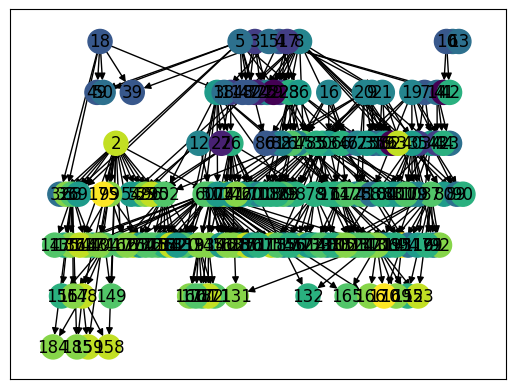

In [105]:
# Gera o gráfico com o histórico de filhos gerados
graph = networkx.DiGraph(histEA.genealogy_tree)
graph = graph.reverse()
colors = [toolbox.evaluate(histEA.genealogy_history[i])[0] for i in graph]
positions = graphviz_layout(graph, prog='dot')
networkx.draw_networkx_labels(graph, positions)
networkx.draw_networkx_nodes(graph, positions, node_color=colors)
networkx.draw_networkx_edges(graph, positions)
plt.savefig('figHistory_eaSimple')
plt.show()

II. eaMuPlusLambda

In [106]:
# Registra os operadores. Deve-se manter os nomes evaluate, mate, mutate e select.
toolbox.register("evaluate", fitnessFunction)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.01)
toolbox.register("select", tools.selBest)

In [107]:
# Gera o objet history
histMuLambda = tools.History()
toolbox.decorate("mate", histMuLambda.decorator)
toolbox.decorate("mutate", histMuLambda.decorator)

In [108]:
# Gera o algoritmo genético com a estrutura e operadores cadastrados
mu = 5
_lambda = 5
pop = toolbox.Populacao(n=mu)
histMuLambda.update(pop)

# Executa o algoritmo eaMuPlusLambda
finalPop, log = algorithms.eaMuPlusLambda(pop, toolbox, mu, _lambda, prob_cx, prob_mt, nger, verbose=False)

# Imprime a melhor solução da população final
melhorSolucao = tools.selBest(finalPop, 1)
print(f'Fitness: {melhorSolucao[0].fitness.values}')

Fitness: (32.0,)


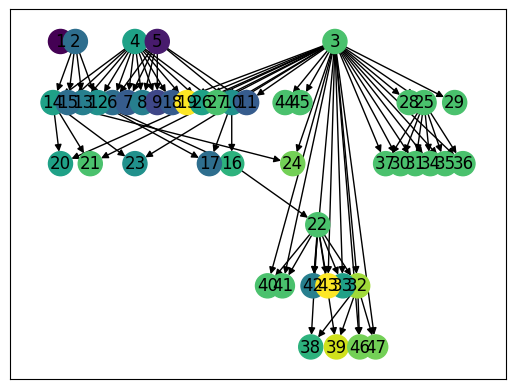

In [109]:
# Gera o gráfico com o histórico de filhos gerados
graph = networkx.DiGraph(histMuLambda.genealogy_tree)
graph = graph.reverse()
colors = [toolbox.evaluate(histMuLambda.genealogy_history[i])[0] for i in graph]
positions = graphviz_layout(graph, prog='dot')
networkx.draw_networkx_labels(graph, positions)
networkx.draw_networkx_nodes(graph, positions, node_color=colors)
networkx.draw_networkx_edges(graph, positions)
plt.savefig('figHistory_eaSimple')
plt.show()

III. eaMuCommaLambda

In [110]:
# Registra os operadores. Deve-se manter os nomes evaluate, mate, mutate e select.
toolbox.register("evaluate", fitnessFunction)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.01)
toolbox.register("select", tools.selBest)

histMuCommaLambda = tools.History()
toolbox.decorate("mate", histMuCommaLambda.decorator)
toolbox.decorate("mutate", histMuCommaLambda.decorator)

In [113]:
# Gera o algoritmo genético com a estrutura e operadores cadastrados
mu = 5
_lambda = 10
pop = toolbox.Populacao(n=mu)
histMuCommaLambda.update(pop)

# Executa o algoritmo eaMuPlusLambda
finalPop, log = algorithms.eaMuPlusLambda(pop, toolbox, mu, _lambda, prob_cx, prob_mt, nger, verbose=False)

# Imprime a melhor solução da população final
melhorSolucao = tools.selBest(finalPop, 1)
print(f'Fitness: {melhorSolucao[0].fitness.values}')

Fitness: (34.0,)


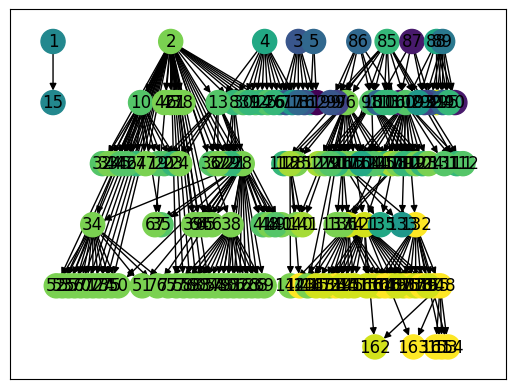

In [114]:
# Gera o gráfico com o histórico de filhos gerados
graph = networkx.DiGraph(histMuCommaLambda.genealogy_tree)
graph = graph.reverse()
colors = [toolbox.evaluate(histMuCommaLambda.genealogy_history[i])[0] for i in graph]
positions = graphviz_layout(graph, prog='dot')
networkx.draw_networkx_labels(graph, positions)
networkx.draw_networkx_nodes(graph, positions, node_color=colors)
networkx.draw_networkx_edges(graph, positions)
plt.savefig('figHistory_MuComma')
plt.show()